In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("netflix_titles.csv")

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.head())

Rows: 8807
Columns: 12
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  Sep

In [4]:
# -------------------------------
# Missing Values
# -------------------------------
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
df['director'] = df['director'].fillna("Not Available")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")

In [6]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [7]:
# -------------------------------
# Convert Date Column
# -------------------------------
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [8]:
# -------------------------------
# Clean Text Columns
# -------------------------------
df['type'] = df['type'].str.lower()
df['country'] = df['country'].str.lower()
df['rating'] = df['rating'].str.lower()
df['listed_in'] = df['listed_in'].str.lower()

In [9]:
# -------------------------------
# Extract Duration Values
# -------------------------------
df['duration'] = df['duration'].astype(str)

df['duration_value'] = df['duration'].str.extract(r'(\d+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

df['movie_minutes'] = np.where(df['type'] == 'movie', df['duration_value'], 0)
df['tv_seasons'] = np.where(df['type'] == 'tv show', df['duration_value'], 0)

In [10]:
# -------------------------------
# Explode Countries
# -------------------------------
df["country"] = df["country"].str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

In [11]:
# -------------------------------
# Netflix Original or Licensed
# -------------------------------
df["content_origin"] = df["description"].str.lower().apply(
    lambda x: "original" if "netflix" in str(x) else "licensed")
print(df["content_origin"].value_counts())

content_origin
licensed    10841
original        9
Name: count, dtype: int64


In [12]:
# -------------------------------
# Extract Date Features
# -------------------------------
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [27]:
df["rating"].value_counts()

rating
tv-ma        3755
tv-14        2406
r            1236
tv-pg        1002
pg-13         769
tv-y7         431
pg            429
tv-y          382
tv-g          244
nr            110
g              62
tv-y7-fv        8
nc-17           5
not rated       4
ur              4
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [28]:
df["listed_in"].unique()

array(['documentaries', 'international tv shows, tv dramas, tv mysteries',
       'crime tv shows, international tv shows, tv action & adventure',
       'docuseries, reality tv',
       'international tv shows, romantic tv shows, tv comedies',
       'tv dramas, tv horror, tv mysteries', 'children & family movies',
       'dramas, independent movies, international movies',
       'british tv shows, reality tv', 'comedies, dramas',
       'crime tv shows, docuseries, international tv shows',
       'dramas, international movies',
       'children & family movies, comedies',
       'british tv shows, crime tv shows, docuseries',
       'tv comedies, tv dramas', 'documentaries, international movies',
       'crime tv shows, spanish-language tv shows, tv dramas',
       'thrillers',
       'international tv shows, spanish-language tv shows, tv action & adventure',
       'international tv shows, tv action & adventure, tv dramas',
       'comedies, international movies',
       'comedies, 

In [29]:
df["listed_in"] = df["listed_in"].str.lower().str.strip()
df["listed_in"] = df["listed_in"].str.split(",")
df = df.explode("listed_in")
df["listed_in"] = df["listed_in"].str.strip()

In [30]:
df['listed_in'].value_counts()

listed_in
international movies            3513
dramas                          3202
comedies                        1981
international tv shows          1465
action & adventure              1182
documentaries                   1118
independent movies              1040
tv dramas                        852
children & family movies         845
thrillers                        806
romantic movies                  722
tv comedies                      630
kids' tv                         596
crime tv shows                   541
horror movies                    458
docuseries                       436
music & musicals                 429
romantic tv shows                384
sci-fi & fantasy                 380
stand-up comedy                  344
british tv shows                 306
reality tv                       270
sports movies                    265
tv action & adventure            204
spanish-language tv shows        202
anime series                     192
korean tv shows             

In [32]:
print(df["duration"])

0          90 min
1       2 Seasons
1       2 Seasons
1       2 Seasons
2        1 Season
          ...    
8805       88 min
8805       88 min
8806      111 min
8806      111 min
8806      111 min
Name: duration, Length: 23764, dtype: object


In [33]:
df["duration_minutes"] = df["duration"].str.extract(r"(\d+) min")
df["duration_seasons"] = df["duration"].str.extract(r"(\d+) Season")
df["duration_minutes"] = df["duration_minutes"].fillna("not available")
df["duration_seasons"] = df["duration_seasons"].fillna("not available")

In [34]:
df=df.drop("duration",axis=1)

In [35]:
df.isnull().any()

show_id             False
type                False
title               False
director            False
cast                False
country             False
date_added           True
release_year        False
rating              False
listed_in           False
description         False
duration_value       True
movie_minutes        True
tv_seasons          False
content_origin      False
year_added           True
month_added          True
duration_minutes    False
duration_seasons    False
dtype: bool

In [36]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,movie_minutes,tv_seasons,content_origin,year_added,month_added,duration_minutes,duration_seasons
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,[united states],2021-09-25,2020,pg-13,documentaries,"As her father nears the end of his life, filmm...",90.0,90.0,0.0,licensed,2021.0,9.0,90,not available


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23764 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           23764 non-null  object        
 1   type              23764 non-null  object        
 2   title             23764 non-null  object        
 3   director          23764 non-null  object        
 4   cast              23764 non-null  object        
 5   country           23764 non-null  object        
 6   date_added        23536 non-null  datetime64[ns]
 7   release_year      23764 non-null  int64         
 8   rating            23764 non-null  object        
 9   listed_in         23764 non-null  object        
 10  description       23764 non-null  object        
 11  duration_value    23761 non-null  float64       
 12  movie_minutes     23761 non-null  float64       
 13  tv_seasons        23764 non-null  float64       
 14  content_origin    23764 non-

In [19]:
# ---------------------------------
# Country Analysis
# ---------------------------------
# Some rows have multiple countries separated by commas
df['country'] = df['country'].fillna("Unknown")
df['country'] = df['country'].str.split(',')
df_country = df.explode('country')
df_country['country'] = df_country['country'].str.strip()
top_countries = df_country['country'].value_counts().head(10)
print(top_countries)

country
united states     3690
india             1046
unknown            831
united kingdom     806
canada             445
france             393
japan              318
spain              232
south korea        231
germany            226
Name: count, dtype: int64


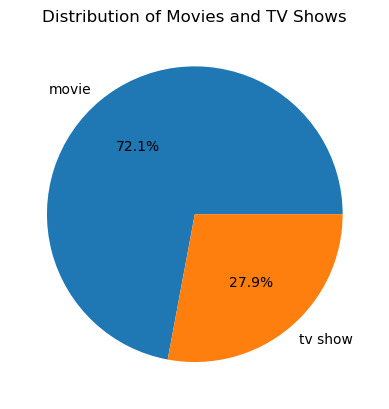

In [13]:
# -------------------------------
# Visualization
# -------------------------------
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Movies and TV Shows")
plt.ylabel("")
plt.show()

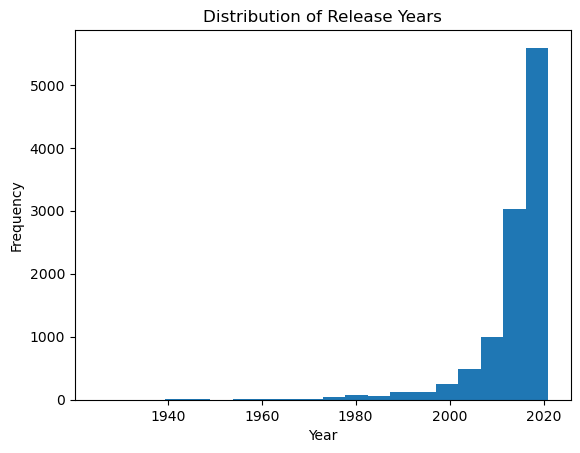

In [14]:
plt.hist(df["release_year"], bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

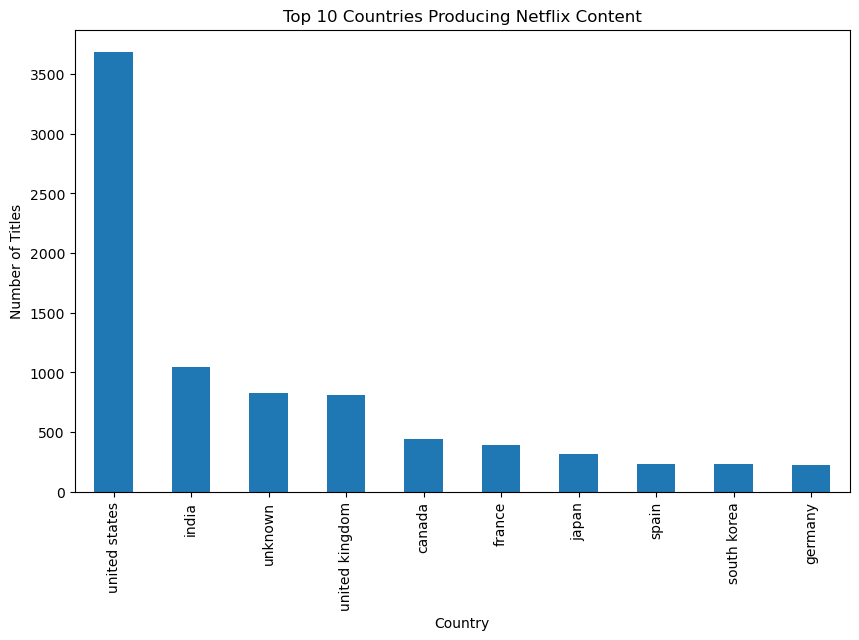

In [20]:
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

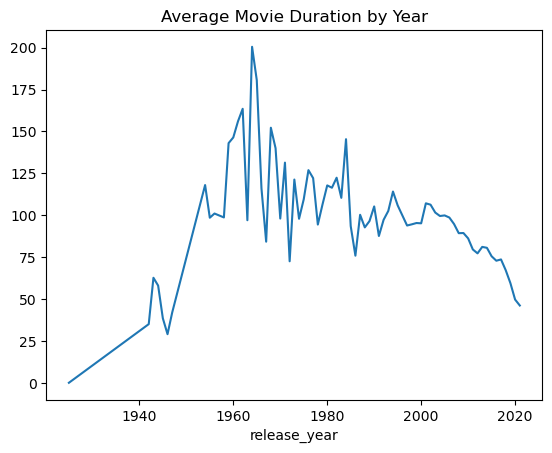

In [15]:
avg_duration = df.groupby("release_year")["movie_minutes"].mean()
avg_duration.plot()
plt.title("Average Movie Duration by Year")
plt.show()

release_year
1925    1
1942    2
1943    3
1944    4
1945    4
Name: count, dtype: int64


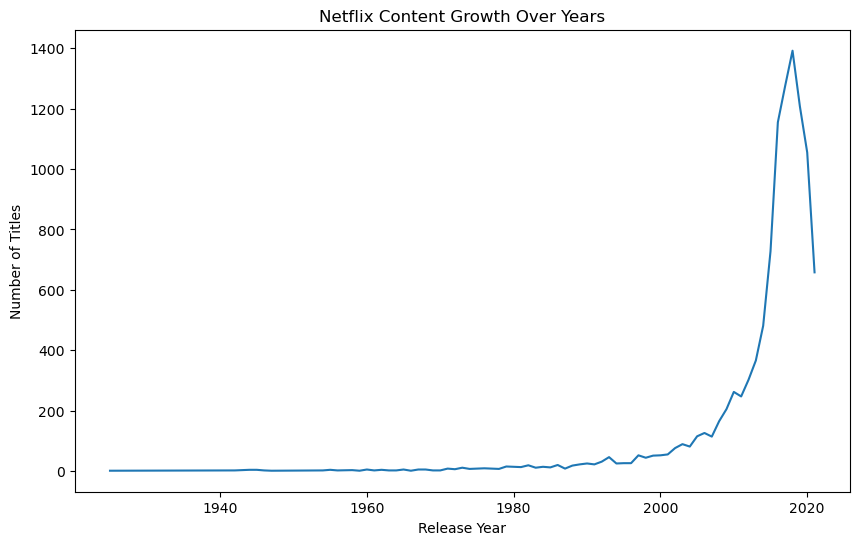

In [22]:
# ---------------------------------
# Netflix Content Growth Over Years
# ---------------------------------
content_growth = df['release_year'].value_counts().sort_index()
print(content_growth.head())
plt.figure(figsize=(10,6))
plt.plot(content_growth.index, content_growth.values)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

type        movie  tv show
year_added                
2008.0        1.0      1.0
2009.0        2.0      NaN
2010.0        1.0      NaN
2011.0       17.0      NaN
2012.0        4.0      NaN


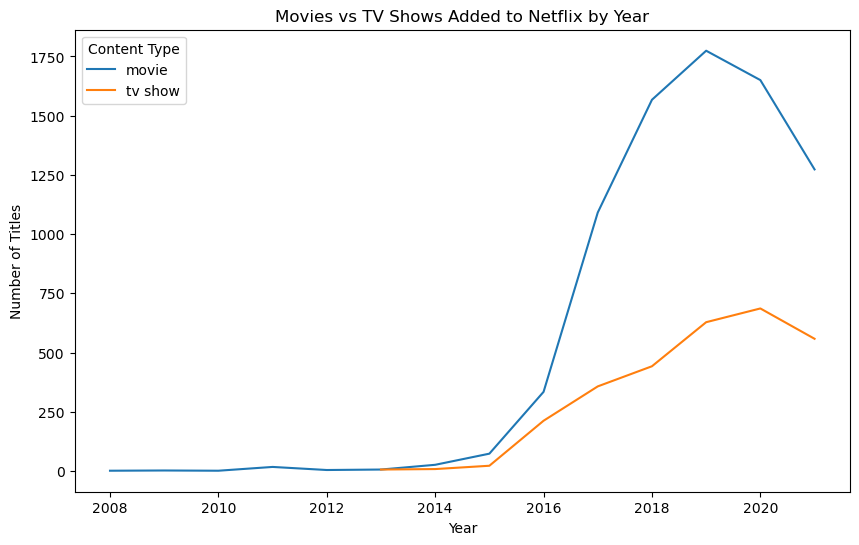

In [24]:
# ---------------------------------
# Movies vs TV Shows Growth by Year
# ---------------------------------
# Extract year from date_added
df['year_added'] = df['date_added'].dt.year
# Group by year and type
content_by_year = df.groupby(['year_added', 'type']).size().unstack()
print(content_by_year.head())
# Plot
content_by_year.plot(kind='line', figsize=(10,6))
plt.title("Movies vs TV Shows Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

In [17]:
# -------------------------------
# Machine Learning Model
# -------------------------------
features = ["release_year","movie_minutes","tv_seasons","year_added","month_added"]

X = df[features].fillna(0)
y = df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1)

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [18]:
# -------------------------------
# Predictions
# -------------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1989    0]
 [   0  724]]
